## Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import iqr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## Load the data

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.conformal.pipeline import run_mondrian_regression

print("cwd:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

file_path = RESULTS_DIR / "SimpleCNN_GN_v1_N5000_seed13_bestval0.5850_predictions_embeddings.npz"

if not file_path.exists():
    raise FileNotFoundError(file_path)

print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("file_path:", file_path)
print("file exists:", file_path.exists())

data = np.load(file_path, allow_pickle=True)
print(data.files)

pred_cal = data["pred_cal"]
y_cal = data["y_cal"]
pred_test = data["pred_test"]
y_test = data["y_test"]

emb_cal = data["emb_cal"]
emb_test = data["emb_test"]

y_mean = data["y_mean"]
y_std = data["y_std"]

label_names = ["chirp_mass", "total_mass", "chi_eff"]

print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("pred_test:", pred_test.shape)
print("y_test:", y_test.shape)
print("emb_cal:", emb_cal.shape)
print("emb_test:", emb_test.shape)
print("y_mean:", y_mean)
print("y_std:", y_std)

cwd: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
PROJECT_ROOT: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe
RESULTS_DIR exists: True
file_path: /home/victor/gw/Gravitational-Waves-Lab/cbc_pe/data/results/SimpleCNN_GN_v1_N5000_seed13_bestval0.5850_predictions_embeddings.npz
file exists: True
['pred_cal', 'emb_cal', 'y_cal', 'pred_test', 'emb_test', 'y_test', 'y_mean', 'y_std', 'checkpoint_file']
pred_cal: (500, 3)
y_cal: (500, 3)
pred_test: (500, 3)
y_test: (500, 3)
emb_cal: (500, 32)
emb_test: (500, 32)
y_mean: [3.7617809e+01 9.5261360e+01 1.5580951e-02]
y_std: [16.548046   34.859104    0.44490194]


## Reverse the standarization and get the physical labels

In [3]:
y_test_phys = y_test * y_std + y_mean

label_ranges_phys = {
    label: np.max(y_test_phys[:, j]) - np.min(y_test_phys[:, j])
    for j, label in enumerate(label_names)
}

label_ranges_phys

{'chirp_mass': np.float32(67.90599),
 'total_mass': np.float32(155.95947),
 'chi_eff': np.float32(1.8701165)}

## Some sanity checks

In [4]:
#Shapes sanity checks
assert pred_cal.ndim == 2
assert pred_test.ndim == 2
assert y_cal.ndim == 2
assert y_test.ndim == 2

assert pred_cal.shape == y_cal.shape
assert pred_test.shape == y_test.shape
assert pred_cal.shape[1] == len(label_names)
assert pred_test.shape[1] == len(label_names)

assert emb_cal.ndim == 2
assert emb_test.ndim == 2
assert emb_cal.shape[0] == pred_cal.shape[0]
assert emb_test.shape[0] == pred_test.shape[0]

assert y_mean.shape[0] == len(label_names)
assert y_std.shape[0] == len(label_names)
assert np.all(y_std > 0)

# Finite-value checks
for name, arr in {
    "pred_cal": pred_cal,
    "y_cal": y_cal,
    "pred_test": pred_test,
    "y_test": y_test,
    "emb_cal": emb_cal,
    "emb_test": emb_test,
    "y_mean": y_mean,
    "y_std": y_std,
}.items():
    assert np.all(np.isfinite(arr)), f"{name} contains NaN or inf"

print("All sanity checks passed.")

All sanity checks passed.


## Compute the metrics for Mondrian

In [5]:
confidence_level = 0.90

n_bins_grid = [4, 6, 8, 12, 16, 24]
taxonomy_modes = ["prediction", "difficulty"]
interval_modes = ["symmetric", "asymmetric"]

n_neighbors = 5
min_samples_per_bin = 10

rows = []
all_results = {}

for taxonomy_mode in taxonomy_modes:
    for interval_mode in interval_modes:
        for n_bins in n_bins_grid:

            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=confidence_level,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=min_samples_per_bin,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=n_neighbors,
                )

            result = run_mondrian_regression(**kwargs)
            all_results[(taxonomy_mode, interval_mode, n_bins)] = result

            metrics = result.metrics

            widths_std = result.upper - result.lower
            widths_phys = widths_std * y_std

            for j, label in enumerate(label_names):
                n_bad_bins_p005 = int(
                    np.nansum(metrics["bin_undercoverage_pvalue"][:, j] < 0.05)
                )

                row = {
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": n_bins,
                    "label": label,
                    "label_index": j,

                    "n_samples": int(metrics["n_samples_per_label"][j]),
                    "covered_count": int(metrics["covered_count_global"][j]),
                    
                    #Global coverage
                    "global_coverage": metrics["global_coverage"][j],
                    "miscoverage": metrics["miscoverage"][j],
                    "global_coverage_gap": metrics["global_coverage_gap"][j],
                    "global_undercoverage_pvalue": metrics["global_undercoverage_pvalue"][j],

                    #Global width
                    "global_mean_width_std": metrics["global_mean_width"][j],
                    "global_median_width_std": metrics["global_median_width"][j],

                    "global_mean_width_phys": np.mean(widths_phys[:, j]),
                    "global_median_width_phys": np.median(widths_phys[:, j]),
                    "global_iqr_width_phys": iqr(widths_phys[:, j]),

                    "normalized_median_width_range": (
                        np.median(widths_phys[:, j]) / label_ranges_phys[label]
                    ),
                    
                    # Bin-wise
                    "min_coverage_per_bin": metrics["min_coverage_per_label"][j],
                    "max_undercoverage_gap": metrics["max_undercoverage_gap"][j],

                    "min_count_per_bin": int(np.nanmin(metrics["counts_per_bin"][:, j])),
                    "max_count_per_bin": int(np.nanmax(metrics["counts_per_bin"][:, j])),

                    "n_bad_bins_p005": n_bad_bins_p005,
                    "bad_bin_fraction": n_bad_bins_p005 / n_bins,

                    "global_lower_miss_rate": metrics["global_lower_miss_rate"][j],
                    "global_upper_miss_rate": metrics["global_upper_miss_rate"][j],
                    "global_tail_miss_imbalance": metrics["global_tail_miss_imbalance"][j],
                }

                global_tol = metrics["global_tolerance_normal"]

                for k in [1, 2, 3]:
                    low = global_tol[f"{k}sigma_low"][j]
                    high = global_tol[f"{k}sigma_high"][j]
                    width = global_tol[f"{k}sigma_width"][j]

                    row[f"global_tol_{k}sigma_low"] = low
                    row[f"global_tol_{k}sigma_high"] = high
                    row[f"global_tol_{k}sigma_width"] = width
                    row[f"global_within_{k}sigma"] = (
                        low <= row["global_coverage"] <= high
                    )

                rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.head()

/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/src/conformal/calibration.py:142: RuntimeWarning: Asymmetric calibration is using an extreme residual for label 0, bin 0. m=32, k_low=1, k_high=31. This usually means the bin has limited samples for equal-tailed calibration and the interval may be conservative.
  interval, indices = self._compute_asymmetric_interval(
/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/src/conformal/calibration.py:142: RuntimeWarning: Asymmetric calibration is using an extreme residual for label 0, bin 1. m=31, k_low=1, k_high=30. This usually means the bin has limited samples for equal-tailed calibration and the interval may be conservative.
  interval, indices = self._compute_asymmetric_interval(
/home/victor/gw/Gravitational-Waves-Lab/cbc_pe/src/conformal/calibration.py:142: RuntimeWarning: Asymmetric calibration is using an extreme residual for label 0, bin 2. m=31, k_low=1, k_high=30. This usually means the bin has limited samples for equal-tailed calibrati

,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_mean_width_phys,global_median_width_phys,global_iqr_width_phys,normalized_median_width_range,min_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bad_bins_p005,bad_bin_fraction,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,global_tol_1sigma_low,global_tol_1sigma_high,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,prediction,symmetric,4,chirp_mass,0,500,463,0.926,0.074,0.026,0.981367,2.406258,2.601813,39.818875,43.054930,2.394581,0.634037,0.912281,0.000000,114,137,0,0.0,0.028,0.046,0.018,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
1,prediction,symmetric,4,total_mass,1,500,467,0.934,0.066,0.034,0.997002,2.376117,2.279166,82.829296,79.449693,8.834680,0.509425,0.905109,0.000000,120,137,0,0.0,0.024,0.042,0.018,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
2,prediction,symmetric,4,chi_eff,2,500,462,0.924,0.076,0.024,0.972570,3.202168,3.189096,1.424651,1.418835,0.033263,0.758688,0.881356,0.018644,115,148,0,0.0,0.052,0.024,0.028,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,True,0.859751,0.940249,0.040249,True
3,prediction,symmetric,6,chirp_mass,0,500,466,0.932,0.068,0.032,0.995053,2.452412,2.601813,40.582635,43.054930,4.514414,0.634037,0.887500,0.012500,71,108,0,0.0,0.026,0.042,0.016,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True
4,prediction,symmetric,6,total_mass,1,500,468,0.936,0.064,0.036,0.998238,2.376790,2.359172,82.852764,82.238626,9.548800,0.527308,0.899083,0.000917,67,109,0,0.0,0.024,0.040,0.016,0.886584,0.913416,0.013416,False,0.873167,0.926833,0.026833,False,0.859751,0.940249,0.040249,True


## Ranking Configurations

### Filtering the configurations

In [6]:
# 1. First we remove the configs that does not pass the pre-cut:
# within 2 sigma nominal CL, min counts per bin is 20 and fraction of bins with statisticall p<5% is less or equal 10 %
candidate_df = summary_df[
    (summary_df["global_within_2sigma"]) &
    (summary_df["min_count_per_bin"] >= 20) &
    (summary_df["bad_bin_fraction"] <= 0.10)
].copy()


# 2. For each label
#   - priorizes low width intervals
#   - and the ties are broken with the lower undercoverage per bin metric.
ranking_df = candidate_df.sort_values(
    ["label", "global_median_width_std", "max_undercoverage_gap"],
    ascending=[True, True, True],
)

ranking_df[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_within_1sigma",
        "global_within_2sigma",
        "global_undercoverage_pvalue",
        "min_coverage_per_bin",
        "max_undercoverage_gap",
        "n_bad_bins_p005",
        "bad_bin_fraction",
        "global_median_width_std",
        "global_median_width_phys",
        "normalized_median_width_range",
        "global_iqr_width_phys",
        "global_lower_miss_rate",
        "global_upper_miss_rate",
        "global_tail_miss_imbalance",
        "min_count_per_bin",
    ]
]


print("Summary configs:", summary_df.groupby("label").size())
print("Passed configs:", candidate_df.groupby("label").size())

Summary configs: label
chi_eff       24
chirp_mass    24
total_mass    24
dtype: int64
Passed configs: label
chi_eff       7
chirp_mass    8
total_mass    5
dtype: int64


### We see the best k configs per label

In [7]:
# best k configs for each label
top_k = 5

top_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(top_k)
)

# show only the following columns
top_by_label[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_median_width_std",
        "global_median_width_phys",
        "bad_bin_fraction",
        "max_undercoverage_gap",
        "global_tail_miss_imbalance",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_median_width_std,global_median_width_phys,bad_bin_fraction,max_undercoverage_gap,global_tail_miss_imbalance
2,chi_eff,prediction,symmetric,4,0.924,3.189096,1.418835,0.000000,0.018644,0.028
14,chi_eff,prediction,symmetric,16,0.922,3.189096,1.418835,0.062500,0.164706,0.018
26,chi_eff,prediction,asymmetric,8,0.918,3.192986,1.420566,0.000000,0.066667,0.006
47,chi_eff,difficulty,symmetric,12,0.920,3.256942,1.449020,0.083333,0.150000,0.020
20,chi_eff,prediction,asymmetric,4,0.926,3.289769,1.463625,0.000000,0.000840,0.006
60,chirp_mass,difficulty,asymmetric,8,0.918,2.362975,39.102619,0.000000,0.031148,0.018
42,chirp_mass,difficulty,symmetric,8,0.912,2.398545,39.691240,0.000000,0.063934,0.000
21,chirp_mass,prediction,asymmetric,6,0.922,2.560263,42.367358,0.000000,0.012500,0.018
6,chirp_mass,prediction,symmetric,8,0.924,2.573922,42.593373,0.000000,0.013208,0.020
0,chirp_mass,prediction,symmetric,4,0.926,2.601813,43.054930,0.000000,0.000000,0.018


## Checking a configuration

In [8]:
def inspect_configuration(
    all_results,
    key,
    label_idx,
    label_names,
):
    result = all_results[key]
    metrics = result.metrics
    label = label_names[label_idx]

    print("Configuration:", key)
    print("Label:", label)

    print("\nCounts per bin:")
    print(metrics["counts_per_bin"][:, label_idx])

    print("\nCoverage per bin:")
    print(np.round(metrics["coverage_per_bin"][:, label_idx], 3))

    print("\nCovered count per bin:")
    print(metrics["covered_count_per_bin"][:, label_idx])

    print("\nBin undercoverage p-values:")
    print(np.round(metrics["bin_undercoverage_pvalue"][:, label_idx], 4))

    print("\nLower miss rate per bin:")
    print(np.round(metrics["lower_miss_rate_per_bin"][:, label_idx], 3))

    print("\nUpper miss rate per bin:")
    print(np.round(metrics["upper_miss_rate_per_bin"][:, label_idx], 3))

    print("\nInterval offsets per bin:")
    print(np.round(result.intervals[label_idx], 4))

    print("\nCalibrator bin counts:")
    print(result.calibrator.bin_counts_[label_idx])

    if hasattr(result.calibrator, "quantile_indices_"):
        print("\nQuantile indices:")
        print(result.calibrator.quantile_indices_[label_idx])

In [9]:
key = ("difficulty", "asymmetric", 12)
inspect_configuration(
    all_results=all_results,
    key=key,
    label_idx=0,
    label_names=label_names,
)

Configuration: ('difficulty', 'asymmetric', 12)
Label: chirp_mass

Counts per bin:
[63 28 35 45 34 36 27 38 31 46 52 65]

Coverage per bin:
[0.921 0.75  0.857 0.778 0.941 1.    0.926 0.921 0.935 0.913 0.942 0.923]

Covered count per bin:
[58 21 30 35 32 36 25 35 29 42 49 60]

Bin undercoverage p-values:
[0.7676 0.0179 0.2693 0.012  0.8671 1.     0.7674 0.7463 0.8304 0.6881
 0.9034 0.7909]

Lower miss rate per bin:
[0.032 0.143 0.143 0.178 0.    0.    0.037 0.053 0.065 0.087 0.058 0.062]

Upper miss rate per bin:
[0.048 0.107 0.    0.044 0.059 0.    0.037 0.026 0.    0.    0.    0.015]

Interval offsets per bin:
[[-0.6985  1.0242]
 [-0.4022  0.9546]
 [-0.8405  1.3523]
 [-0.63    1.3136]
 [-1.0885  1.0582]
 [-1.0575  1.5843]
 [-1.4703  1.3264]
 [-1.0586  1.3378]
 [-0.5965  2.4022]
 [-0.9519  1.7371]
 [-1.285   1.332 ]
 [-1.3116  1.5498]]

Calibrator bin counts:
[42 42 41 42 41 42 42 41 42 41 42 42]

Quantile indices:
[[ 2 40]
 [ 2 40]
 [ 2 39]
 [ 2 40]
 [ 2 39]
 [ 2 40]
 [ 2 40]
 [ 2 39]

## Plots

In [41]:
plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue",
}


def plot_global_coverage_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        if df_tax.empty:
            ax.set_title(f"{taxonomy_mode} (no data)")
            continue

        # Global tolerance is constant for this label.
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhspan(low_1, high_1, alpha=0.20, label=r"$1\sigma$")
        ax.axhspan(low_2, high_2, alpha=0.15, label=r"$2\sigma$")
        ax.axhspan(low_3, high_3, alpha=0.10, label=r"$3\sigma$")

        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level * 100)}%",
        )

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Global coverage", fontsize=13)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper left",
        bbox_to_anchor=(0.82, 1.08),
        ncol=2,
    )

    plt.show()

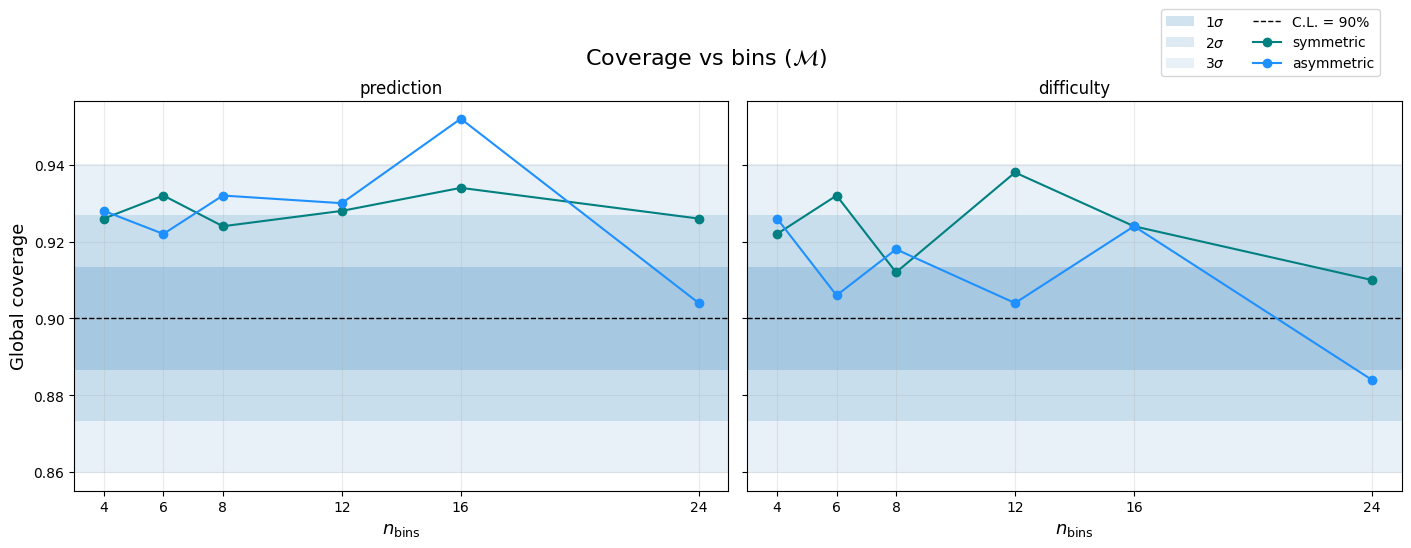

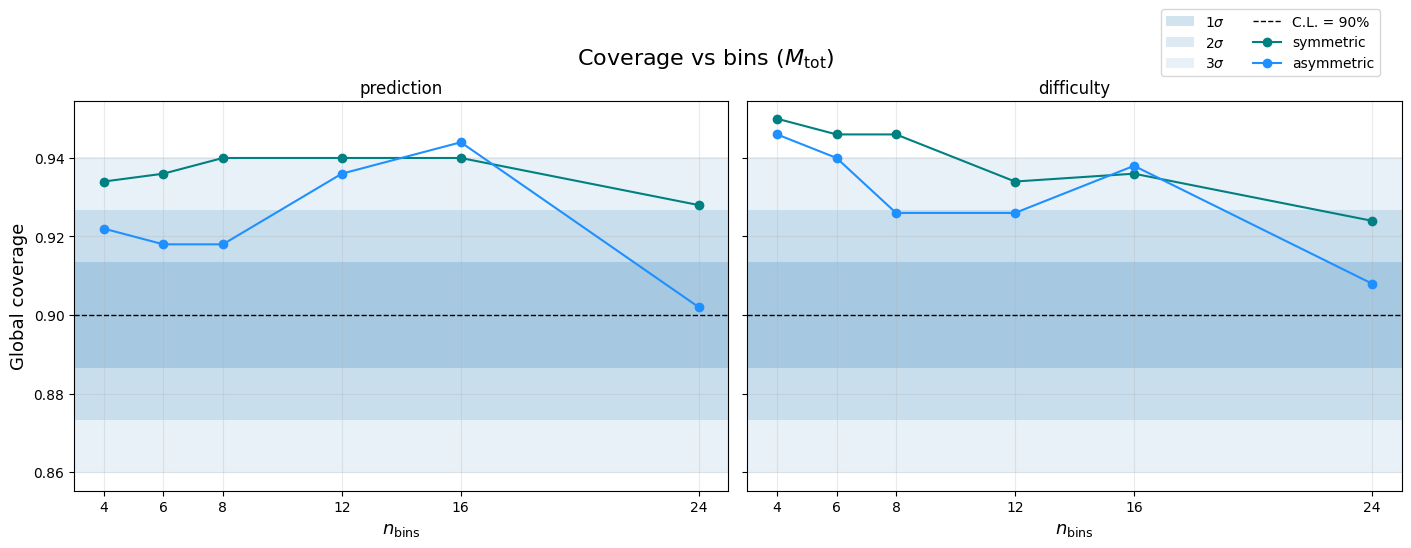

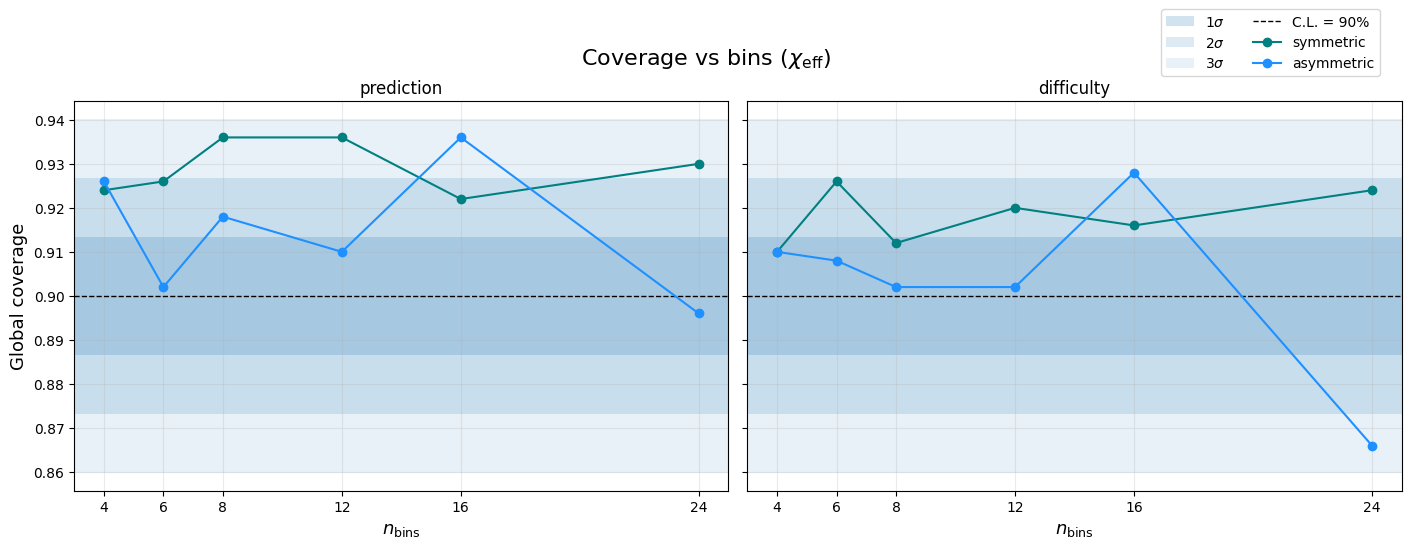

In [42]:
for label in label_names:
    plot_global_coverage_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        plot_colors=plot_colors,
    )

In [12]:
def plot_width_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    plot_labels,
    width_column="global_median_width_std",
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode[width_column],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_title(taxonomy_mode)
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(width_column, fontsize=13)
    fig.suptitle(f"Interval width vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=2,
    )

    plt.show()

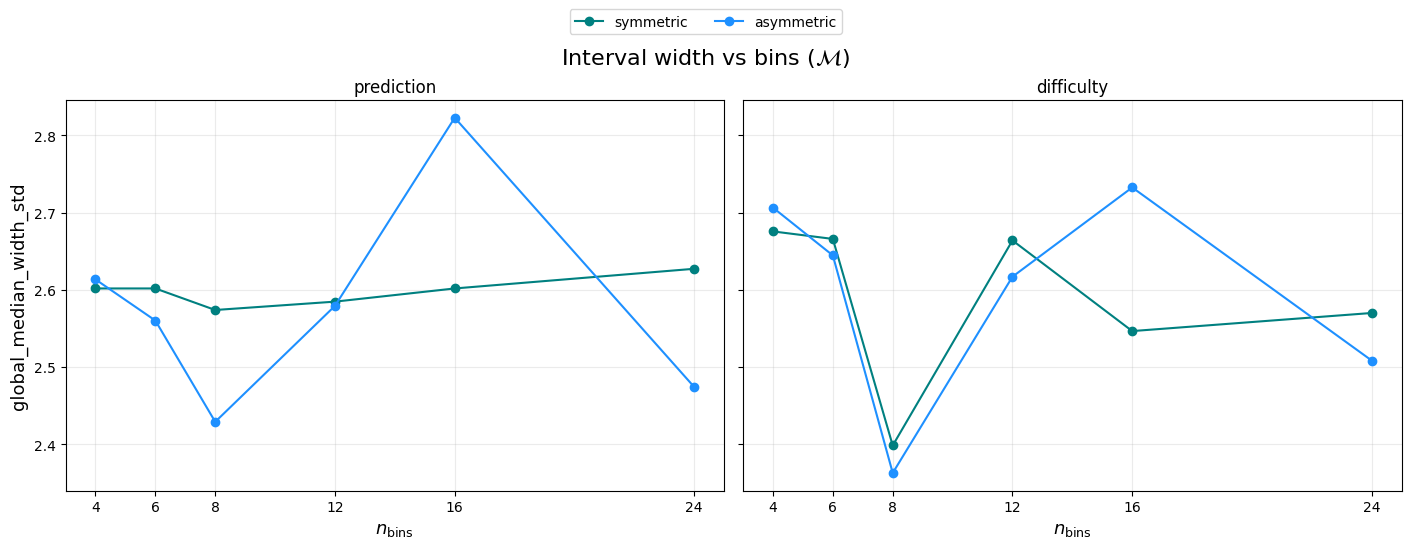

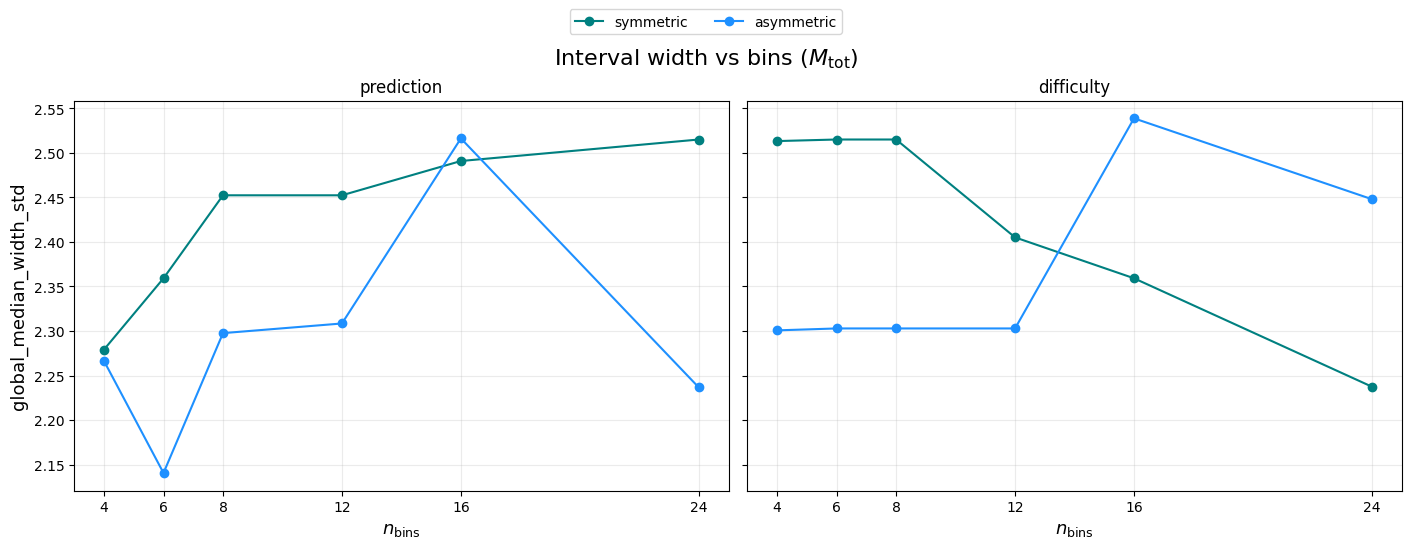

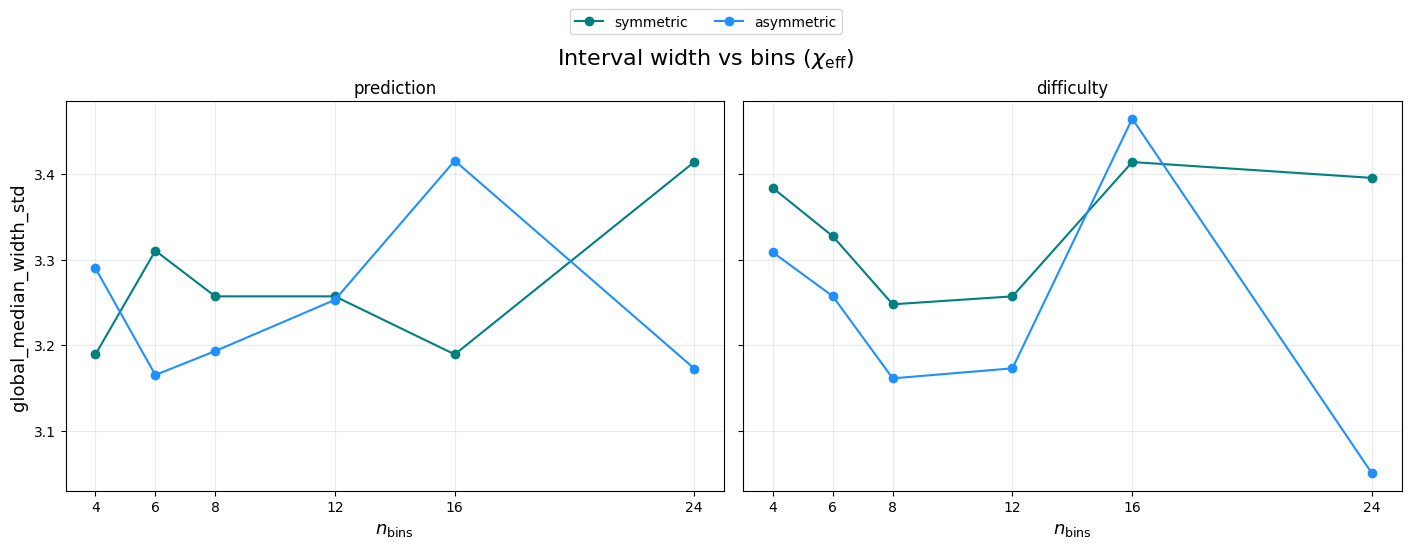

In [13]:
for label in label_names:
    plot_width_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        plot_labels=plot_labels,
        width_column="global_median_width_std",
        plot_colors=plot_colors,
    )

In [28]:
def plot_coverage_width_tradeoff(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    width_column="global_median_width_std",
):
    df_label = summary_df[summary_df["label"] == label]

    scatter_color = {

    }

    plt.figure(figsize=(16, 10))

    for taxonomy_mode in taxonomy_modes:
        for interval_mode in interval_modes:
            df_mode = df_label[
                (df_label["taxonomy_mode"] == taxonomy_mode) &
                (df_label["interval_mode"] == interval_mode)
            ]

            plt.scatter(
                df_mode[width_column],
                df_mode["global_coverage"],
                s=150,
                label=f"{taxonomy_mode}-{interval_mode}",
            )

            for _, row in df_mode.iterrows():
                plt.text(
                    row[width_column],
                    row["global_coverage"],
                    str(row["n_bins"]),
                    fontsize=8,
                    ha="center",
                    va="center",
                    color="white",
                )

    plt.axhline(confidence_level, color="black", linestyle="--", linewidth=1)
    plt.xlabel(width_column)
    plt.ylabel("Global coverage")
    plt.title(f"Coverage-efficiency tradeoff ({plot_labels[label]})")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

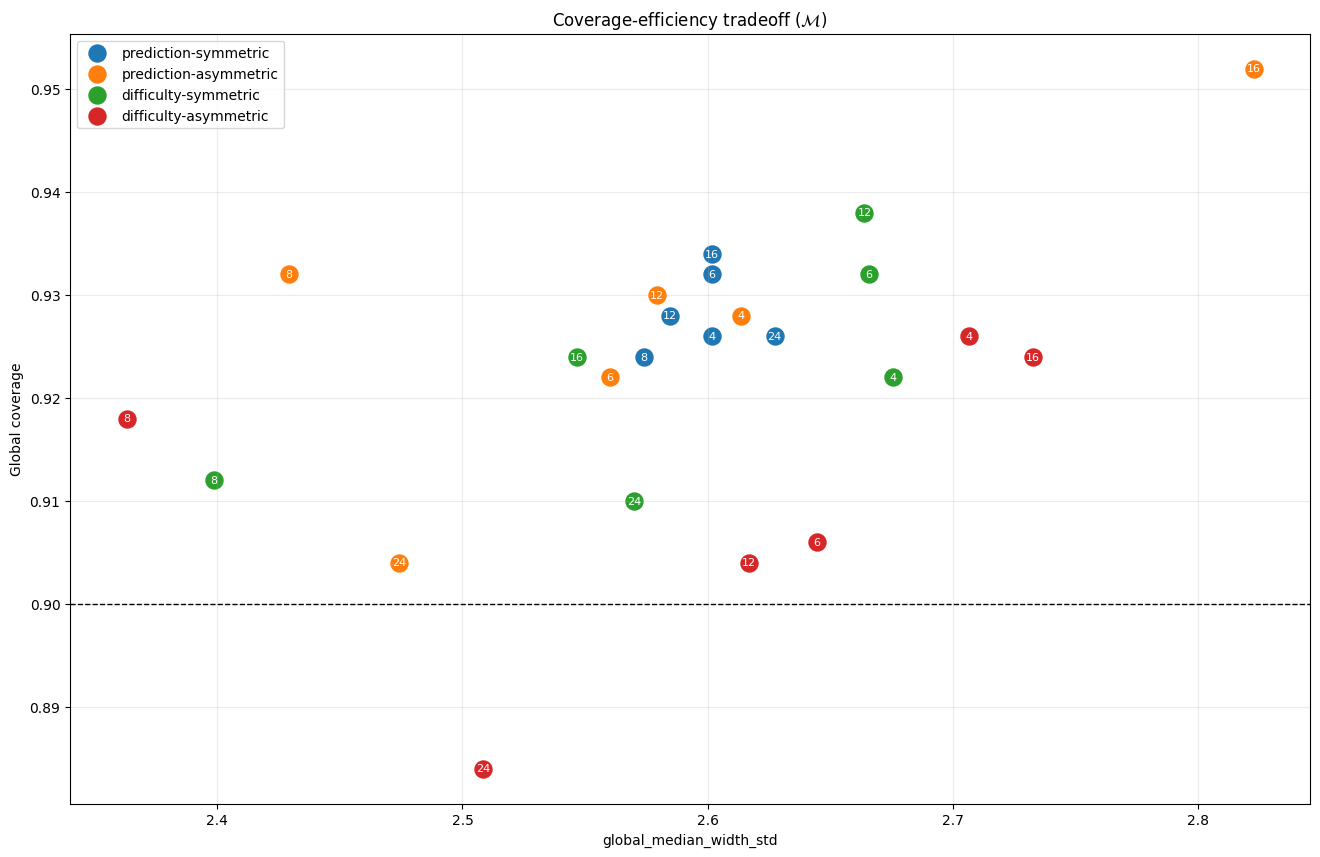

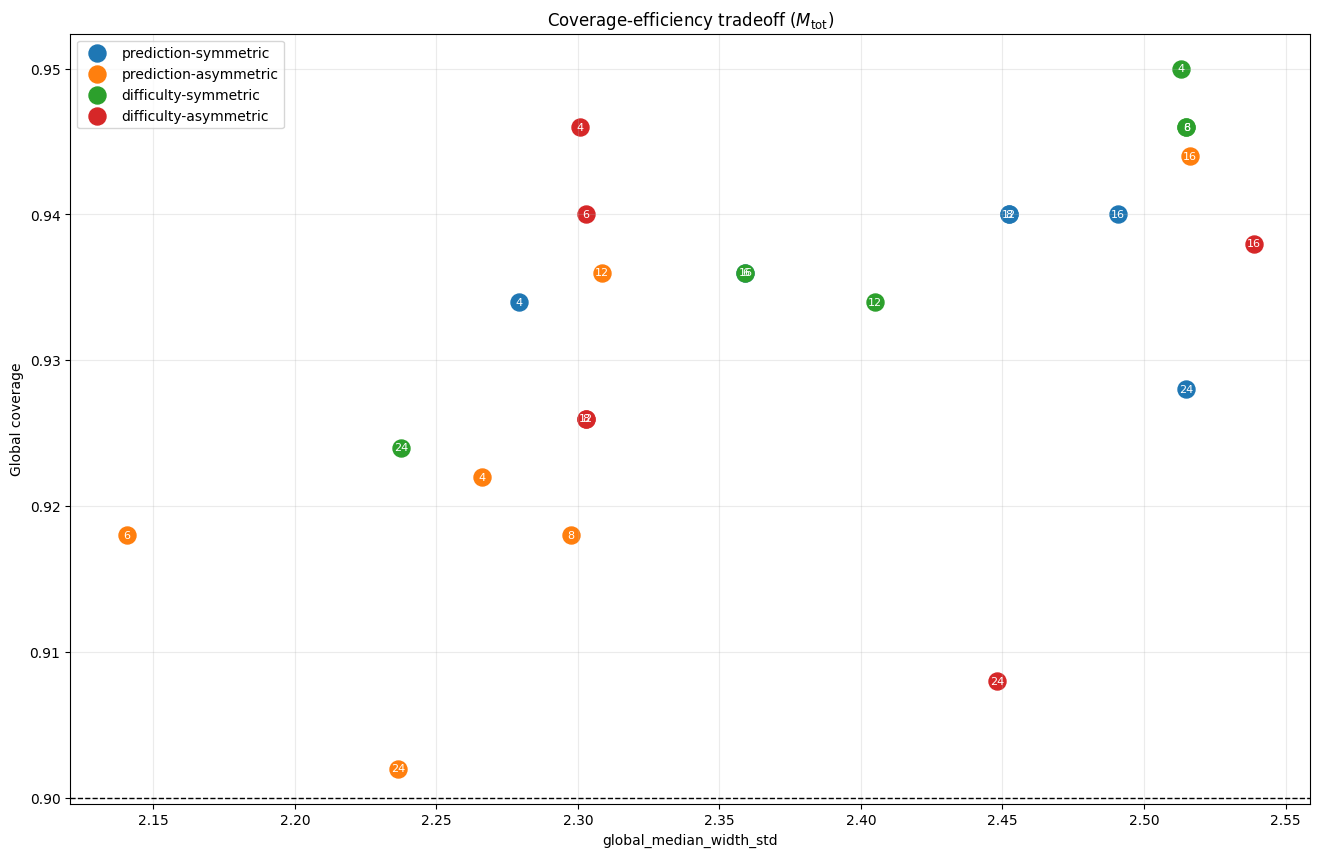

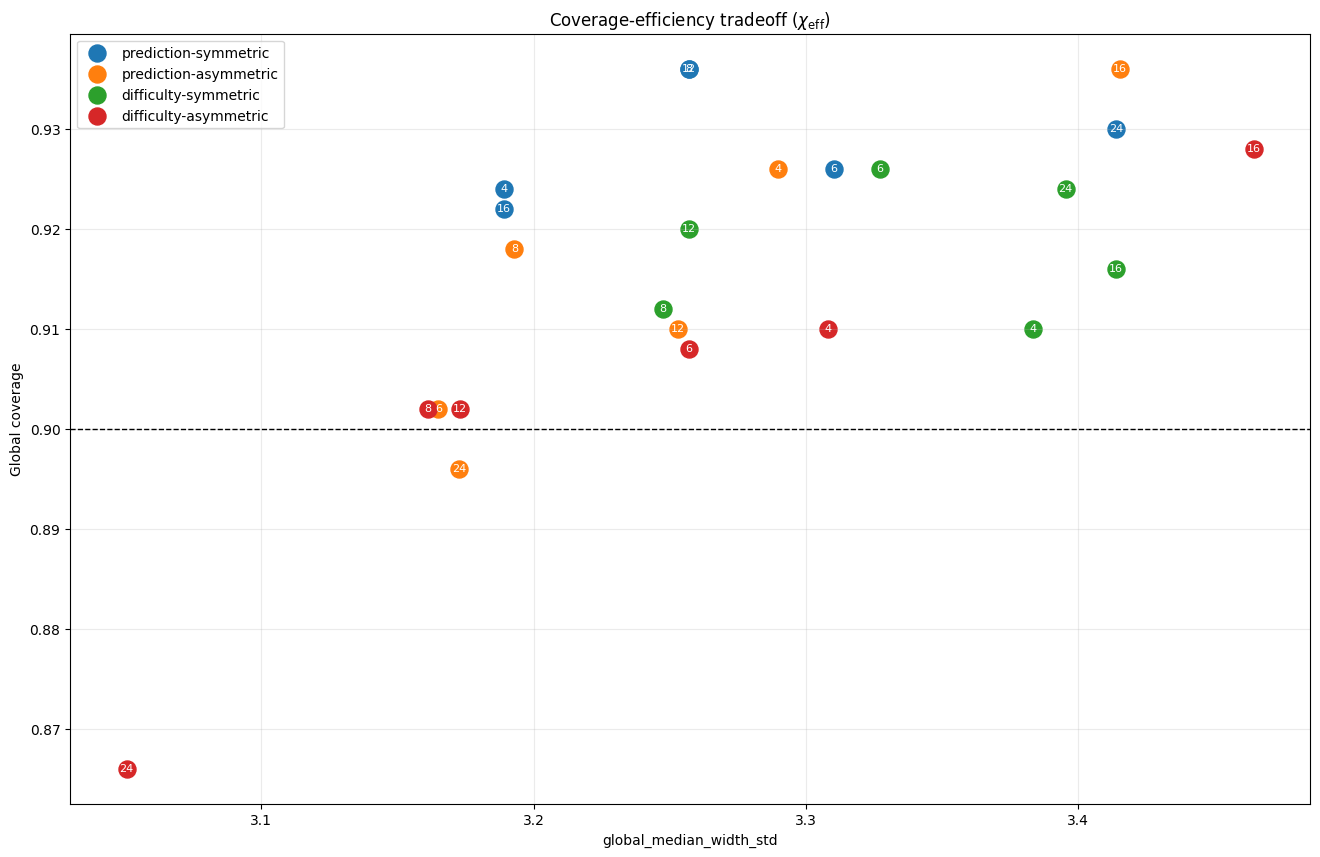

In [29]:
for label in label_names:
    plot_coverage_width_tradeoff(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        width_column="global_median_width_std",
    )

In [16]:
def plot_coverage_per_bin(
    all_results,
    key,
    label_idx,
    label_names,
    plot_labels,
    confidence_level,
):
    result = all_results[key]
    metrics = result.metrics

    label = label_names[label_idx]

    coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
    counts_per_bin = metrics["counts_per_bin"][:, label_idx]
    bin_tol = metrics["bin_tolerance_normal"]

    x = np.arange(len(coverage_per_bin))

    low_1 = bin_tol["1sigma_low"][:, label_idx]
    low_2 = bin_tol["2sigma_low"][:, label_idx]
    low_3 = bin_tol["3sigma_low"][:, label_idx]

    high_1 = bin_tol["1sigma_high"][:, label_idx]
    high_2 = bin_tol["2sigma_high"][:, label_idx]
    high_3 = bin_tol["3sigma_high"][:, label_idx]

    band_color = "tab:red"

    plt.figure(figsize=(9, 5))

    plt.fill_between(
        x, low_3, high_3,
        color=band_color,
        alpha=0.10,
        label=r"Nominal 3$\sigma$",
        zorder=1,
    )
    plt.fill_between(
        x, low_2, high_2,
        color=band_color,
        alpha=0.15,
        label=r"Nominal 2$\sigma$",
        zorder=2,
    )
    plt.fill_between(
        x, low_1, high_1,
        color=band_color,
        alpha=0.20,
        label=r"Nominal 1$\sigma$",
        zorder=3,
    )

    plt.plot(
        x,
        coverage_per_bin,
        marker="o",
        color="maroon",
        label="Empirical coverage",
        zorder=4,
    )

    plt.axhline(
        confidence_level,
        linestyle="--",
        alpha=0.5,
        linewidth=1.0,
        color="black",
        label=rf"C.L. = {confidence_level}",
    )

    for i, n in enumerate(counts_per_bin):
        plt.text(
            i,
            coverage_per_bin[i] - 0.03,
            str(n),
            ha="center",
            fontsize=10,
            color="k",
        )

    plt.xlabel("Bin index")
    plt.ylabel("Coverage")
    plt.title(f"Coverage per bin | {plot_labels[label]} | {key}")
    plt.ylim(0.65, 1.02)
    plt.legend(ncols=2, loc="lower right")
    plt.grid(alpha=0.25)
    plt.show()

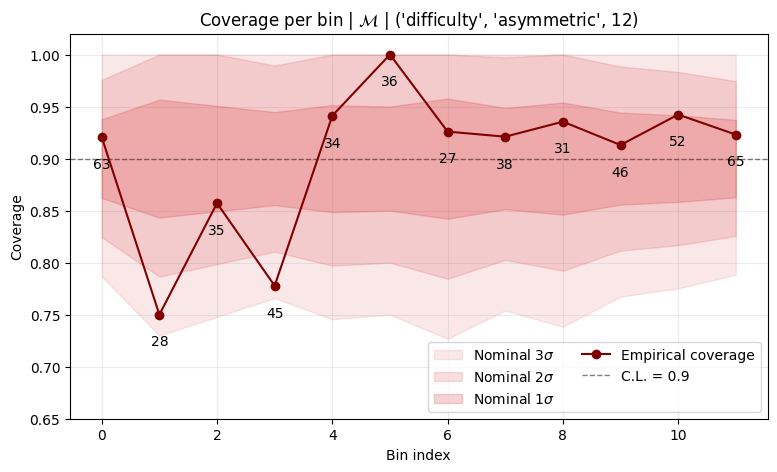

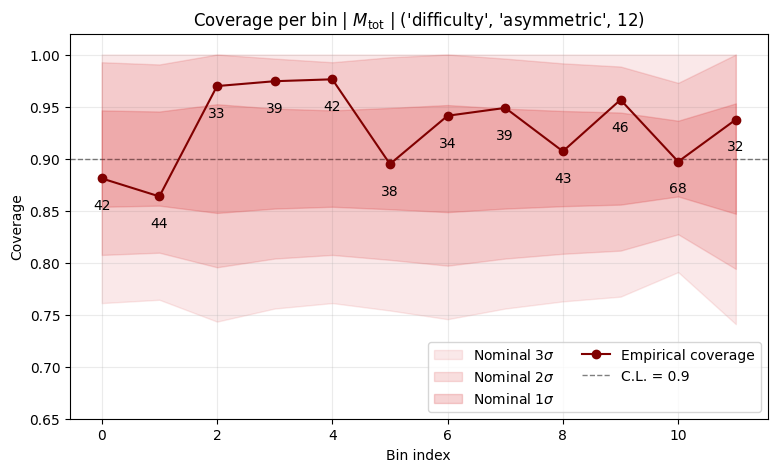

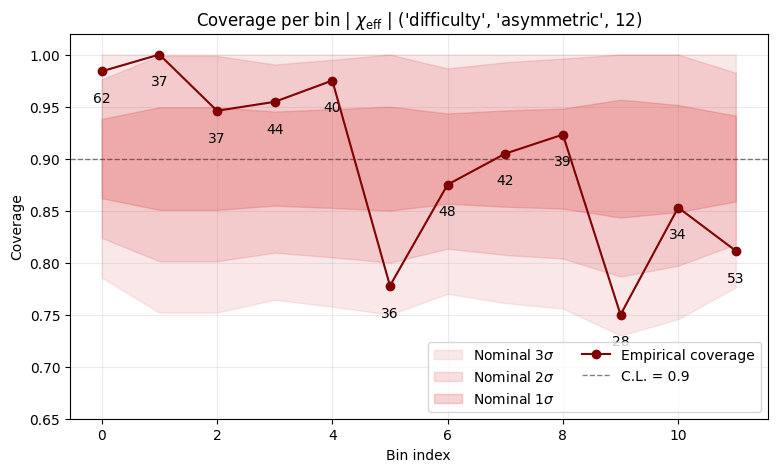

In [17]:
key = ("difficulty", "asymmetric", 12)

for label_idx in range(len(label_names)):
    plot_coverage_per_bin(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
        plot_labels=plot_labels,
        confidence_level=confidence_level,
    )

## Final candidate configuration

In [18]:
best_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(1)
)

best_by_label[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_median_width_std",
        "global_median_width_phys",
        "bad_bin_fraction",
        "max_undercoverage_gap",
        "global_tail_miss_imbalance",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_median_width_std,global_median_width_phys,bad_bin_fraction,max_undercoverage_gap,global_tail_miss_imbalance
2,chi_eff,prediction,symmetric,4,0.924,3.189096,1.418835,0.0,0.018644,0.028
60,chirp_mass,difficulty,asymmetric,8,0.918,2.362975,39.102619,0.0,0.031148,0.018
22,total_mass,prediction,asymmetric,6,0.918,2.140537,74.617199,0.0,0.035802,0.018


Configuration: ('prediction', 'symmetric', 4)
Label: chi_eff

Counts per bin:
[148 115 119 118]

Coverage per bin:
[0.973 0.939 0.891 0.881]

Covered count per bin:
[144 108 106 104]

Bin undercoverage p-values:
[0.9999 0.9487 0.4119 0.2907]

Lower miss rate per bin:
[0.014 0.035 0.067 0.102]

Upper miss rate per bin:
[0.014 0.026 0.042 0.017]

Interval offsets per bin:
[[-1.6285  1.6285]
 [-1.5911  1.5911]
 [-1.5832  1.5832]
 [-1.5945  1.5945]]

Calibrator bin counts:
[125 125 125 125]

Quantile indices:
[[113 113]
 [113 113]
 [113 113]
 [113 113]]


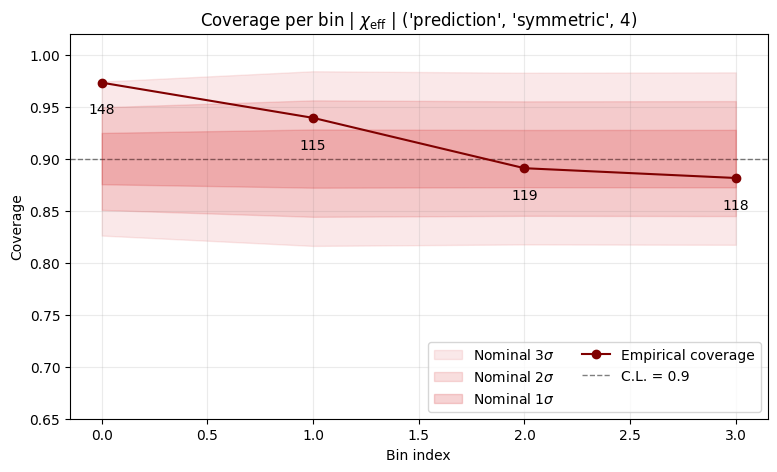

Configuration: ('difficulty', 'asymmetric', 8)
Label: chirp_mass

Counts per bin:
[73 53 61 54 39 57 68 95]

Coverage per bin:
[0.904 0.887 0.869 0.963 0.923 0.947 0.941 0.916]

Covered count per bin:
[66 47 53 52 36 54 64 87]

Bin undercoverage p-values:
[0.6038 0.4392 0.263  0.9763 0.7622 0.9334 0.9184 0.745 ]

Lower miss rate per bin:
[0.055 0.094 0.082 0.    0.026 0.018 0.059 0.053]

Upper miss rate per bin:
[0.041 0.019 0.049 0.037 0.051 0.035 0.    0.032]

Interval offsets per bin:
[[-0.5613  1.0242]
 [-0.8405  1.2741]
 [-0.8351  1.2644]
 [-1.0575  1.2794]
 [-1.1811  1.1819]
 [-1.2427  1.5095]
 [-1.3617  1.7371]
 [-1.285   1.333 ]]

Calibrator bin counts:
[63 62 63 62 62 63 62 63]

Quantile indices:
[[ 3 60]
 [ 3 59]
 [ 3 60]
 [ 3 59]
 [ 3 59]
 [ 3 60]
 [ 3 59]
 [ 3 60]]


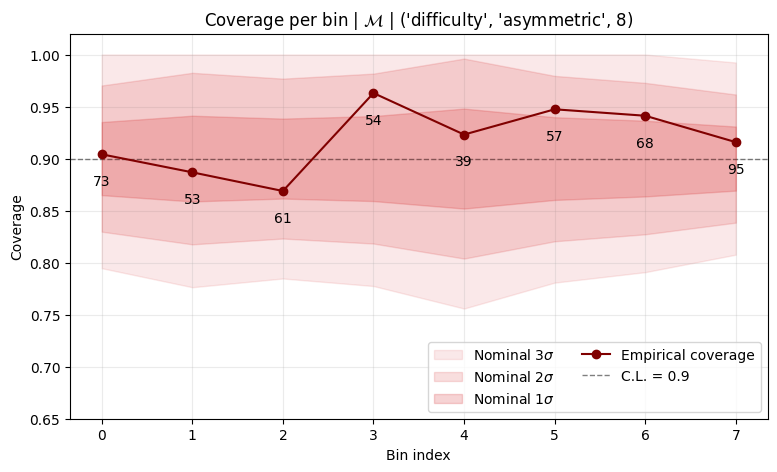

Configuration: ('prediction', 'asymmetric', 6)
Label: total_mass

Counts per bin:
[ 73  83  87  67  81 109]

Coverage per bin:
[0.918 0.952 0.943 0.925 0.864 0.908]

Covered count per bin:
[67 79 82 62 70 99]

Bin undercoverage p-values:
[0.7501 0.9716 0.9434 0.8124 0.1837 0.6597]

Lower miss rate per bin:
[0.055 0.024 0.011 0.06  0.086 0.064]

Upper miss rate per bin:
[0.027 0.024 0.046 0.015 0.049 0.028]

Interval offsets per bin:
[[-0.6492  1.5457]
 [-1.0689  1.647 ]
 [-0.9163  1.2566]
 [-0.6747  1.2704]
 [-0.8807  1.2597]
 [-1.1187  1.0218]]

Calibrator bin counts:
[84 83 83 83 83 84]

Quantile indices:
[[ 4 80]
 [ 4 79]
 [ 4 79]
 [ 4 79]
 [ 4 79]
 [ 4 80]]


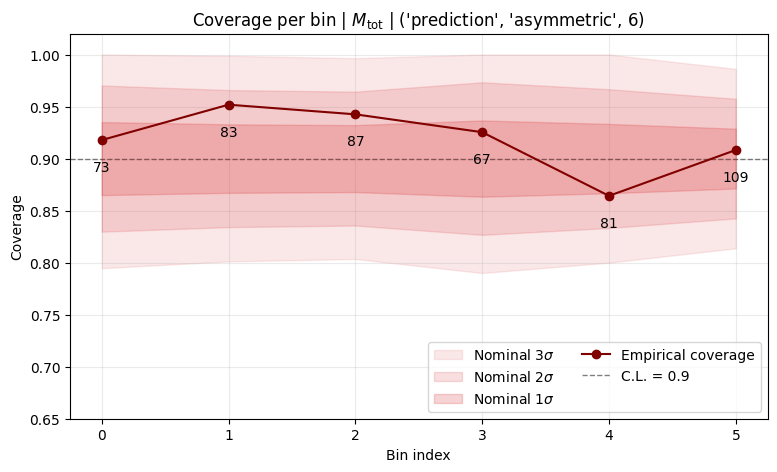

In [19]:
for row in best_by_label.itertuples():
    key = (row.taxonomy_mode, row.interval_mode, row.n_bins)
    label_idx = row.label_index

    inspect_configuration(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
    )

    plot_coverage_per_bin(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
        plot_labels=plot_labels,
        confidence_level=confidence_level,
    )

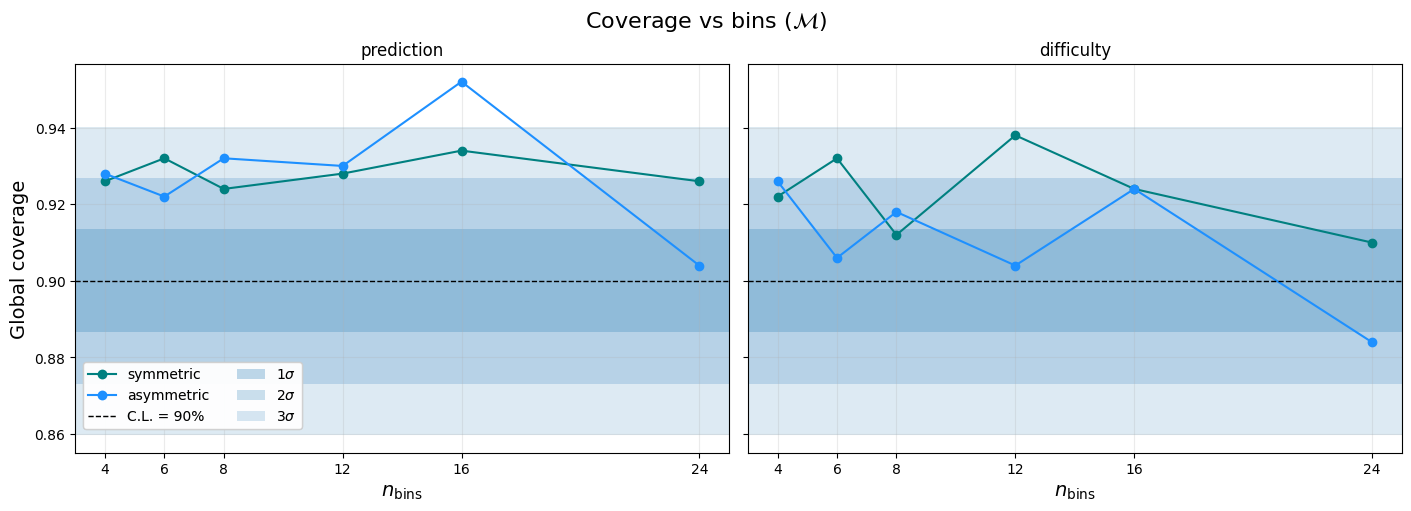

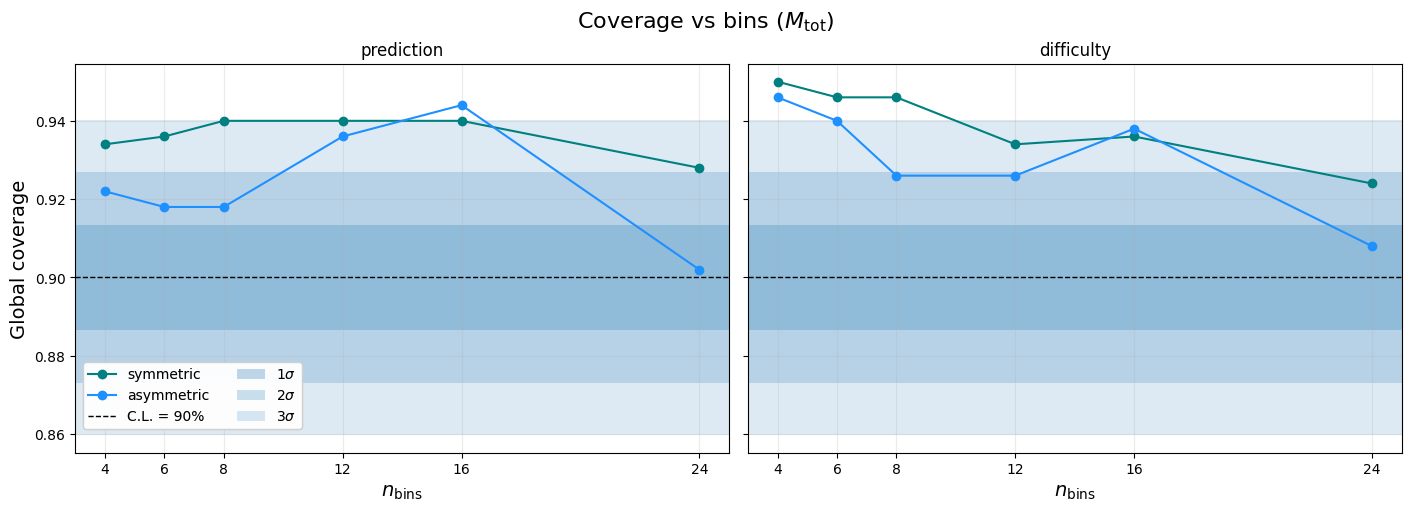

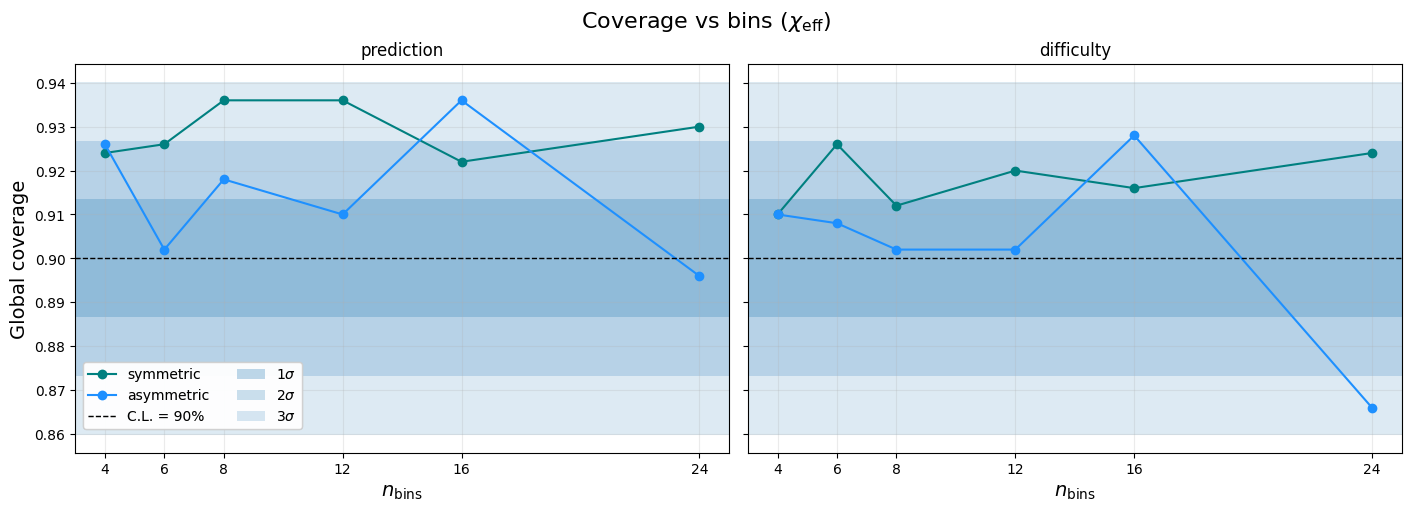

In [20]:
import numpy as np
import matplotlib.pyplot as plt

plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue", 
}

for label in label_names:
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    # Por si taxonomy_modes tuviera longitud 1
    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=plot_colors[interval_mode],
            )

        # Tolerancias globales: para este label, n debería ser constante
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level*100)}%",
        )

        ax.axhspan(low_1, high_1, alpha=0.25, label=r"$1\sigma$")
        ax.axhspan(low_2, high_2, alpha=0.20, label=r"$2\sigma$")
        ax.axhspan(low_3, high_3, alpha=0.15, label=r"$3\sigma$")
        

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=14)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

        handles, labels_legend = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels_legend,
            loc="upper left",
            bbox_to_anchor=(0.05, 0.30),
            ncol=2,
        )

    axes[0].set_ylabel("Global coverage", fontsize=14)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    

    plt.show()

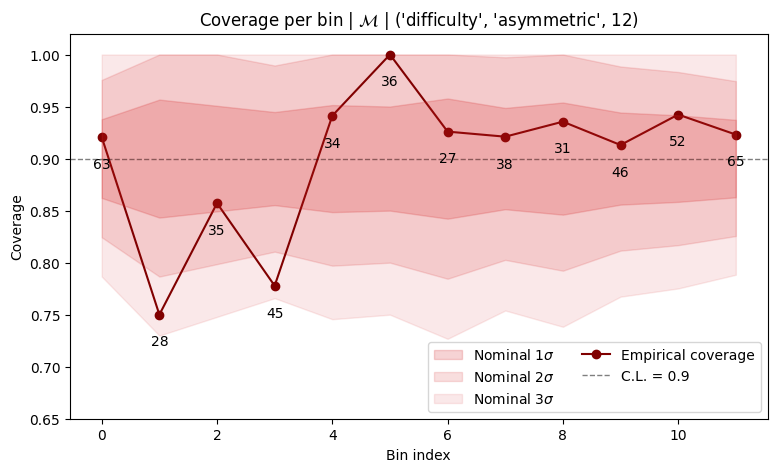

In [21]:
key = ("difficulty", "asymmetric", 12)
result = all_results[key]
metrics = result.metrics

label_idx = 0
label = label_names[label_idx]

coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
counts_per_bin = metrics["counts_per_bin"][:, label_idx]
bin_tol = metrics["bin_tolerance_normal"]

x = np.arange(len(coverage_per_bin))

low_1 = bin_tol["1sigma_low"][:, label_idx]
low_2 = bin_tol["2sigma_low"][:, label_idx]
low_3 = bin_tol["3sigma_low"][:, label_idx]
high_1 = bin_tol["1sigma_high"][:, label_idx]
high_2 = bin_tol["2sigma_high"][:, label_idx] 

high_3 = bin_tol["3sigma_high"][:, label_idx]

band_color = "tab:red"

plt.figure(figsize=(9, 5))


plt.fill_between(x, low_1, high_1, color=band_color, alpha=0.20, label=r"Nominal 1$\sigma$", zorder=3)
plt.fill_between(x, low_2, high_2, color=band_color, alpha=0.15, label=r"Nominal 2$\sigma$", zorder=2)
plt.fill_between(x, low_3, high_3, color=band_color, alpha=0.10, label=r"Nominal 3$\sigma$", zorder=1)
plt.plot(x, coverage_per_bin, marker="o", color="maroon", label="Empirical coverage" )
plt.axhline(confidence_level, linestyle="--", alpha=0.5, linewidth=1.0, color="black", label=rf"C.L. = {confidence_level}")

for i, n in enumerate(counts_per_bin):
    plt.text(i, coverage_per_bin[i] - 0.03, str(n), ha="center", fontsize=10, color="k")

plt.xlabel("Bin index")
plt.ylabel("Coverage")
plt.title(f"Coverage per bin | {plot_labels[label]} | {key}")
plt.ylim(0.65, 1.02)
plt.legend(ncols=2, loc="lower right")
plt.show()